In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
df = pd.read_csv("../dataset/processed/cleaned_movies.csv", encoding='latin1')
df.head()

,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,2019,109.0,268,7.0,8,811,1782,2815,377
1,2019,110.0,207,4.4,35,1749,1589,890,2572
2,1997,147.0,177,4.7,827,2005,508,85,2449
3,2005,142.0,331,7.4,1086,2643,931,1388,3030
4,2012,82.0,367,5.6,326,174,2521,1461,1205


In [3]:
# create features and ytaarget
x = df.drop('Rating', axis = 1)
y = df['Rating']

In [4]:
print(x.shape)
print(y.shape)

(7919, 8)
(7919,)


In [5]:
# train-test split
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size = 0.2,
    random_state=42
)


In [6]:
print("Training samples: ", x_train.shape)
print("Testing samples: ", y_train.shape)

Training samples:  (6335, 8)
Testing samples:  (6335,)


In [7]:
lr = LinearRegression()
lr.fit(x_train,y_train)
lr_pred = lr.predict(x_test)

In [8]:
# decision tree
dt = DecisionTreeRegressor(
    random_state=42
)

dt.fit(x_train, y_train)
dt_pred = dt.predict(x_test)

In [9]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(x_train, y_train)

rf_pred = rf.predict(x_test)

In [10]:
# function to evaluate
def evaluate_model(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    mse = mean_squared_error(y_true, y_pred)

    rmse = mse ** 0.5

    r2 = r2_score(y_true, y_pred)

    return mae, rmse, r2

Evaluating models one by one

In [11]:
# lr
lr_mae, lr_rmse, lr_r2 = evaluate_model(
    y_test,
    lr_pred
)

In [12]:
# dt
dt_mae, dt_rmse, dt_r2 = evaluate_model(
    y_test,
    dt_pred
)

In [13]:
#rf
rf_mae, rf_rmse, rf_r2 = evaluate_model(
    y_test,
    rf_pred
)

In [14]:
# compare
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        lr_mae,
        dt_mae,
        rf_mae
    ],
    "RMSE": [
        lr_rmse,
        dt_rmse,
        rf_rmse
    ],
    "R2 Score": [
        lr_r2,
        dt_r2,
        rf_r2
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.031247,1.293056,0.100665
1,Decision Tree,1.163321,1.546797,-0.286926
2,Random Forest,0.831389,1.100451,0.348630


In [15]:
#best model
results.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,MAE,RMSE,R2 Score
2,Random Forest,0.831389,1.100451,0.348630
0,Linear Regression,1.031247,1.293056,0.100665
1,Decision Tree,1.163321,1.546797,-0.286926


In [16]:
# Random forest - feature importance
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
3,Votes,0.215250
0,Year,0.197153
2,Genre,0.123976
7,Actor 3,0.095665
5,Actor 1,0.094773
6,Actor 2,0.094185
1,Duration,0.093338
4,Director,0.085661


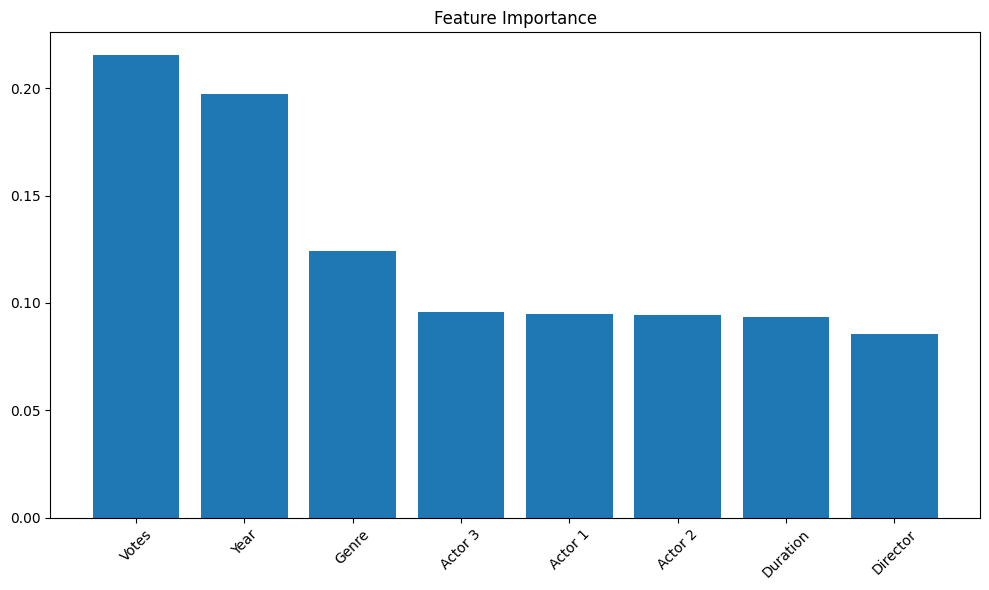

In [17]:
#plotting
plt.figure(figsize=(10,6))

plt.bar(
    importance['Feature'],
    importance['Importance']
)

plt.xticks(rotation=45)

plt.title("Feature Importance")

plt.tight_layout()

plt.show()

In [18]:
# sample predictions
comparison = pd.DataFrame({
    'Actual Rating': y_test,
    'Predicted Rating': rf_pred
})

comparison.head(10)

,Actual Rating,Predicted Rating
4896,3.3,4.4110
7538,5.3,5.1935
1677,5.7,4.8485
1964,7.2,5.6225
3025,3.5,5.2535
6260,7.2,5.9185
6306,3.8,5.7165
2436,6.9,6.9405
4526,5.2,5.6945
2464,7.4,5.8835


In [ ]:
# saving best model
import joblib
joblib.dump(
    rf,
    "../models/movie_rating_model.pkl"
)

['../models/movie_rating_model.pkl']

Key Findings

1. The dataset was cleaned by handling missing values.
2. Categorical features such as Genre, Director, and Actors were encoded.
3. Three regression models were trained:
   - Linear Regression
   - Decision Tree Regressor
   - Random Forest Regressor
4. Random Forest achieved the best performance.
5. Votes and Director were among the most influential features.